# Evaluating the output of the SCIP solver of CVXPY

In [2]:
from av_mat_generation.CI_based.window import Window
from datetime import datetime
import pandas as pd
import numpy as np
import cvxpy as cp
import random
import time

MAIN_FOLDER = 'availability_matrices/av-mat-scalability'
start_time=datetime(2022, 1, 1, 0, 0)
max_rounds=90
ft=1

In [3]:
# Diff nb clients: 
nb_clients_list = [7, 14, 28, 54, 108, 216, 432, 864, 1000]
# Diff base training time T (equiv to carbon budget)
T = [90, 75, 60, 45, 30, 15, 5, 3] #train time list
# Diff s: 
s_list = [20, 40, 60, 80, 100]

In [5]:
from datetime import timedelta
from math import ceil

alpha_f = 0.1
BASE_K = 54            # number of distinct country data files available
SPACING_DAYS = 15      # gap between artificial copies -> distinct months = distinct clients
MAXH = max(t + s for t in T for s in s_list)   # widest horizon ever needed (= 190)
DATA_END = datetime(2022, 12, 31, 23)          # last hour present in historical_data


def build_GHG(target_K, n_rounds):
    """Fabricate `target_K` clients from the BASE_K countries by stacking copies
    sampled at SPACING_DAYS-shifted start times (same country at a different month
    -> different CI -> a distinct client), then keep the first `target_K` rows.
    For target_K <= BASE_K this returns exactly the same matrix as
    custom_client_list=target_K (the country shuffle is seeded)."""
    m = ceil(target_K / BASE_K)
    mats = []
    for j in range(m):
        st = start_time + timedelta(days=SPACING_DAYS * j)
        assert st + timedelta(hours=n_rounds - 1) <= DATA_END, (
            f"copy {j} window (start {st}, {n_rounds} rounds) runs past the 2022 data; "
            f"reduce target_K or SPACING_DAYS"
        )
        win = Window(
            start_time=st,
            out_folder=MAIN_FOLDER,
            n_rounds=n_rounds,
            custom_client_list=BASE_K,
        )
        mats.append(win.get_GHG_matrix().to_numpy().astype(float))
    return np.vstack(mats)[:target_K]

In [ ]:


nb_clients_list = [7, 14, 28, 54, 108, 
                #    216, 432, 864, 1000
                   ]
# Diff base training time T (equiv to carbon budget)
T = [90, 75, 60, 45, 30, 15, 5, 3] #train time list
# Diff s: 
s_list = [20, 40, 60, 80, 100]

timing_records = []

for nb_clients in nb_clients_list:
    # Build the widest matrix once; every (T, s) slice is a time-prefix of it.
    G = build_GHG(nb_clients, MAXH)  # (nb_clients, MAXH)
    # budget for each T = total emissions of all clients over the first T rounds
    carbon_budget_considered = np.array([G[:, :Tv].sum() for Tv in T])
    print(carbon_budget_considered)
    for ii, carbon_budget in enumerate(carbon_budget_considered):
        Tv = T[ii]
        print(Tv)
        for s in s_list:
            n_solve = Tv + s - ft            # training rounds actually optimised (win)
            GHG_mat = G[:, :n_solve]         # (nb_clients, T + s - ft)
            tail = G[:, n_solve:Tv + s].sum()  # last ft cols of the T+s window (win1)
            corrected_budget = carbon_budget - tail
            record = dict(
                nb_clients=nb_clients,
                T=Tv,
                s=s,
                n_rounds=n_solve,
                corrected_budget=corrected_budget,
            )
            try:
                # same problem construction as Window._av_mat_alphaF_cvxpy, without plotting/saving
                w = np.ones(n_solve)
                one_m_GHG_w = (np.max(GHG_mat) - GHG_mat) @ np.diag(w)
                t0 = time.perf_counter()
                x = cp.Variable(GHG_mat.shape, integer=True)
                objective = cp.Maximize(
                    cp.sum(
                        cp.power(cp.sum(cp.multiply(one_m_GHG_w, x), axis=1), alpha_f)
                    )
                )
                constraints = [
                    0 <= x,
                    x <= 1,
                    cp.sum(cp.multiply(GHG_mat, x)) <= corrected_budget,
                ]
                prob = cp.Problem(objective, constraints)
                t1 = time.perf_counter()
                # prob.solve(solver=cp.MOSEK, 
                #            mosek_params={
                #                 "MSK_DPAR_MIO_TOL_REL_GAP": 1e-2,   # or stop once within 1% of the optimum
                #             }
                #            )
                prob.solve(
                    solver=cp.SCIP,
                    scip_params={
                        "limits/totalnodes": -1,
                        # "limits/gap": 1e-2,  # stop once provably within 1% of the optimum
                        "limits/time": 1800,
                    },
                )
                t2 = time.perf_counter()

                record.update(
                    build_seconds=t1 - t0,
                    solve_seconds=t2 - t1,
                    scip_seconds=getattr(prob.solver_stats, "solve_time", None),
                    status=prob.status,
                    objective_value=prob.value,
                    achieved_GHG=(
                        float(np.sum(GHG_mat * x.value))
                        if x.value is not None
                        else None
                    ),
                )
                print(
                    f"{nb_clients} clients | T={Tv} s={s} ({n_solve} rnds): solve {t2 - t1:.2f}s, status {prob.status}"
                )
            except Exception as e:
                record.update(status=f"failed: {e}")
                print(f"Failed! Exception: {e}")
            timing_records.append(record)
            # keep partial results on disk in case the sweep is interrupted
            pd.DataFrame(timing_records).to_csv(
                MAIN_FOLDER + "/alphaF_solve_times.csv", index=False
            )

timing_df = pd.DataFrame(timing_records)
timing_df

[65.522364 53.755497 42.573672 32.100399 21.724482 10.646118  3.46971
  2.091123]
90
7 clients | T=90 s=20 (109 rnds): solve 0.05s, status optimal
7 clients | T=90 s=40 (129 rnds): solve 0.05s, status optimal
7 clients | T=90 s=60 (149 rnds): solve 0.05s, status optimal


/home/danny/Documents/prjkts/GreenFL/venv/lib/python3.10/site-packages/mosek/__init__.py:11539: UserWarning: Argument subi in putaijlist64: Incorrect array format causing data to be copied
  warnings.warn("Argument subi in putaijlist64: Incorrect array format causing data to be copied");
/home/danny/Documents/prjkts/GreenFL/venv/lib/python3.10/site-packages/mosek/__init__.py:11568: UserWarning: Argument subj in putaijlist64: Incorrect array format causing data to be copied
  warnings.warn("Argument subj in putaijlist64: Incorrect array format causing data to be copied");


7 clients | T=90 s=80 (169 rnds): solve 0.07s, status optimal
7 clients | T=90 s=100 (189 rnds): solve 0.06s, status optimal
75
7 clients | T=75 s=20 (94 rnds): solve 0.10s, status optimal
7 clients | T=75 s=40 (114 rnds): solve 0.07s, status optimal
7 clients | T=75 s=60 (134 rnds): solve 0.05s, status optimal
7 clients | T=75 s=80 (154 rnds): solve 0.08s, status optimal
7 clients | T=75 s=100 (174 rnds): solve 0.06s, status optimal
60
7 clients | T=60 s=20 (79 rnds): solve 0.08s, status optimal
7 clients | T=60 s=40 (99 rnds): solve 0.63s, status optimal
7 clients | T=60 s=60 (119 rnds): solve 0.06s, status optimal
7 clients | T=60 s=80 (139 rnds): solve 0.06s, status optimal
7 clients | T=60 s=100 (159 rnds): solve 0.14s, status optimal
45
7 clients | T=45 s=20 (64 rnds): solve 0.05s, status optimal
7 clients | T=45 s=40 (84 rnds): solve 0.08s, status optimal
7 clients | T=45 s=60 (104 rnds): solve 0.06s, status optimal
7 clients | T=45 s=80 (124 rnds): solve 0.17s, status optimal
7

/home/danny/Documents/prjkts/GreenFL/venv/lib/python3.10/site-packages/mosek/__init__.py:11539: UserWarning: Argument subi in putaijlist64: Incorrect array format causing data to be copied
  warnings.warn("Argument subi in putaijlist64: Incorrect array format causing data to be copied");
/home/danny/Documents/prjkts/GreenFL/venv/lib/python3.10/site-packages/mosek/__init__.py:11568: UserWarning: Argument subj in putaijlist64: Incorrect array format causing data to be copied
  warnings.warn("Argument subj in putaijlist64: Incorrect array format causing data to be copied");


14 clients | T=90 s=40 (129 rnds): solve 0.15s, status optimal
14 clients | T=90 s=60 (149 rnds): solve 0.17s, status optimal
14 clients | T=90 s=80 (169 rnds): solve 0.81s, status optimal
14 clients | T=90 s=100 (189 rnds): solve 0.22s, status optimal
75
14 clients | T=75 s=20 (94 rnds): solve 0.14s, status optimal
14 clients | T=75 s=40 (114 rnds): solve 0.22s, status optimal
14 clients | T=75 s=60 (134 rnds): solve 0.70s, status optimal
14 clients | T=75 s=80 (154 rnds): solve 0.18s, status optimal
14 clients | T=75 s=100 (174 rnds): solve 0.16s, status optimal
60
14 clients | T=60 s=20 (79 rnds): solve 0.17s, status optimal
14 clients | T=60 s=40 (99 rnds): solve 0.19s, status optimal
14 clients | T=60 s=60 (119 rnds): solve 0.17s, status optimal
14 clients | T=60 s=80 (139 rnds): solve 0.19s, status optimal
14 clients | T=60 s=100 (159 rnds): solve 0.24s, status optimal
45
14 clients | T=45 s=20 (64 rnds): solve 0.11s, status optimal
14 clients | T=45 s=40 (84 rnds): solve 0.20s, 

...

216 clients | T=90 s=20 (109 rnds): solve 4.19s, status optimal
216 clients | T=90 s=40 (129 rnds): solve 4.32s, status optimal
216 clients | T=90 s=60 (149 rnds): solve 4.96s, status optimal
216 clients | T=90 s=80 (169 rnds): solve 5.06s, status optimal
216 clients | T=90 s=100 (189 rnds): solve 4019.27s, status optimal
75
216 clients | T=75 s=20 (94 rnds): solve 2.61s, status optimal
216 clients | T=75 s=40 (114 rnds): solve 3.49s, status optimal
216 clients | T=75 s=60 (134 rnds): solve 141.64s, status optimal
216 clients | T=75 s=80 (154 rnds): solve 4.56s, status optimal
216 clients | T=75 s=100 (174 rnds): solve 5.20s, status optimal
60
216 clients | T=60 s=20 (79 rnds): solve 14.19s, status optimal
216 clients | T=60 s=40 (99 rnds): solve 39.73s, status optimal
216 clients | T=60 s=60 (119 rnds): solve 3.63s, status optimal
216 clients | T=60 s=80 (139 rnds): solve 292.56s, status optimal
216 clients | T=60 s=100 (159 rnds): solve 4.74s, status optimal
45
216 clients | T=45 s=2

/home/danny/Documents/prjkts/GreenFL/venv/lib/python3.10/site-packages/mosek/__init__.py:11539: UserWarning: Argument subi in putaijlist64: Incorrect array format causing data to be copied
  warnings.warn("Argument subi in putaijlist64: Incorrect array format causing data to be copied");
/home/danny/Documents/prjkts/GreenFL/venv/lib/python3.10/site-packages/mosek/__init__.py:11568: UserWarning: Argument subj in putaijlist64: Incorrect array format causing data to be copied
  warnings.warn("Argument subj in putaijlist64: Incorrect array format causing data to be copied");


432 clients | T=90 s=20 (109 rnds): solve 564.48s, status optimal
432 clients | T=90 s=40 (129 rnds): solve 1510.30s, status optimal
432 clients | T=90 s=60 (149 rnds): solve 2217.98s, status optimal
432 clients | T=90 s=80 (169 rnds): solve 11.67s, status optimal
432 clients | T=90 s=100 (189 rnds): solve 12.12s, status optimal
75
432 clients | T=75 s=20 (94 rnds): solve 101.29s, status optimal
432 clients | T=75 s=40 (114 rnds): solve 8.92s, status optimal
432 clients | T=75 s=60 (134 rnds): solve 10.41s, status optimal
432 clients | T=75 s=80 (154 rnds): solve 175.60s, status optimal
432 clients | T=75 s=100 (174 rnds): solve 11.76s, status optimal
60
432 clients | T=60 s=20 (79 rnds): solve 1507.50s, status optimal
432 clients | T=60 s=40 (99 rnds): solve 7.39s, status optimal
432 clients | T=60 s=60 (119 rnds): solve 8.60s, status optimal
432 clients | T=60 s=80 (139 rnds): solve 12258.18s, status optimal
432 clients | T=60 s=100 (159 rnds): solve 11.23s, status optimal
45
432 cli

/home/danny/Documents/prjkts/GreenFL/venv/lib/python3.10/site-packages/mosek/__init__.py:11539: UserWarning: Argument subi in putaijlist64: Incorrect array format causing data to be copied
  warnings.warn("Argument subi in putaijlist64: Incorrect array format causing data to be copied");
/home/danny/Documents/prjkts/GreenFL/venv/lib/python3.10/site-packages/mosek/__init__.py:11568: UserWarning: Argument subj in putaijlist64: Incorrect array format causing data to be copied
  warnings.warn("Argument subj in putaijlist64: Incorrect array format causing data to be copied");


864 clients | T=90 s=20 (109 rnds): solve 297.24s, status optimal
864 clients | T=90 s=40 (129 rnds): solve 6066.08s, status optimal
864 clients | T=90 s=60 (149 rnds): solve 7383.43s, status optimal
864 clients | T=90 s=80 (169 rnds): solve 21.56s, status optimal
864 clients | T=90 s=100 (189 rnds): solve 22.05s, status optimal
75
864 clients | T=75 s=20 (94 rnds): solve 19.24s, status optimal
864 clients | T=75 s=40 (114 rnds): solve 21.72s, status optimal
864 clients | T=75 s=60 (134 rnds): solve 20.90s, status optimal
864 clients | T=75 s=80 (154 rnds): solve 21.52s, status optimal
864 clients | T=75 s=100 (174 rnds): solve 21.73s, status optimal
60
864 clients | T=60 s=20 (79 rnds): solve 16.45s, status optimal
864 clients | T=60 s=40 (99 rnds): solve 20.25s, status optimal
864 clients | T=60 s=60 (119 rnds): solve 289.95s, status optimal
864 clients | T=60 s=80 (139 rnds): solve 6535.09s, status optimal
864 clients | T=60 s=100 (159 rnds): solve 21.59s, status optimal
45
864 clie

# Greedy runs

In [6]:
import time
from av_mat_generation.CI_based.greedy_improv import GreedyProblem

alpha_f = 0.1
timing_records_greedy = []

for nb_clients in nb_clients_list:
    win0 = Window(start_time=start_time, out_folder=MAIN_FOLDER, n_rounds=max_rounds, custom_client_list=nb_clients)
    res = win0.get_GHG_matrix()
    carbon_budget_considered = res.sum().cumsum().to_numpy().take([89,74,59,44,29,14,4,2])
    print(carbon_budget_considered)
    for ii, carbon_budget in enumerate(carbon_budget_considered):
        print(T[ii])
        for s in s_list:
            win1 = Window(start_time=start_time, out_folder=MAIN_FOLDER, n_rounds=T[ii]+s, custom_client_list=nb_clients)
            win = Window(start_time=start_time, out_folder=MAIN_FOLDER, n_rounds=T[ii]+s-ft, custom_client_list=nb_clients)
            corrected_budget = carbon_budget - win1.get_GHG_matrix().to_numpy()[:, -ft:].sum()
            record = dict(nb_clients=nb_clients, T=T[ii], s=s, n_rounds=win.n_rounds, corrected_budget=corrected_budget)
            try:
                # same computation as Window._av_mat_alphaF_greedy, without plotting
                GHG_df = win.get_GHG_matrix()
                w = np.ones(win.n_rounds)

                t0 = time.perf_counter()
                pb = GreedyProblem(GHG_df, alpha_f, w)
                t1 = time.perf_counter()
                pb.greedy_optimization(corrected_budget)
                t2 = time.perf_counter()

                record.update(
                    build_seconds=t1 - t0,
                    solve_seconds=t2 - t1,
                    status="greedy_done",
                    objective_value=pb.obj_func(pb.A),
                    achieved_GHG=float(np.sum(pb.GHG_mat * pb.A)),
                )
                print(f"{nb_clients} clients | T={T[ii]} s={s} ({win.n_rounds} rnds): greedy {t2 - t1:.2f}s")
            except Exception as e:
                record.update(status=f"failed: {e}")
                print(f"Failed! Exception: {e}")
            timing_records_greedy.append(record)
            # separate CSV so the SCIP timings are not overwritten
            pd.DataFrame(timing_records_greedy).to_csv(MAIN_FOLDER + "/alphaF_greedy_solve_times.csv", index=False)

timing_df_greedy = pd.DataFrame(timing_records_greedy)
timing_df_greedy

[65.52236399999998 53.75549699999999 42.573671999999995 32.100399
 21.724482000000002 10.646117999999998 3.46971 2.091123]
90
7 clients | T=90 s=20 (109 rnds): greedy 0.01s
7 clients | T=90 s=40 (129 rnds): greedy 0.02s
7 clients | T=90 s=60 (149 rnds): greedy 0.02s
7 clients | T=90 s=80 (169 rnds): greedy 0.02s
7 clients | T=90 s=100 (189 rnds): greedy 0.02s
75
7 clients | T=75 s=20 (94 rnds): greedy 0.01s
7 clients | T=75 s=40 (114 rnds): greedy 0.01s
7 clients | T=75 s=60 (134 rnds): greedy 0.02s
7 clients | T=75 s=80 (154 rnds): greedy 0.02s
7 clients | T=75 s=100 (174 rnds): greedy 0.02s
60
7 clients | T=60 s=20 (79 rnds): greedy 0.01s
7 clients | T=60 s=40 (99 rnds): greedy 0.01s
7 clients | T=60 s=60 (119 rnds): greedy 0.01s
7 clients | T=60 s=80 (139 rnds): greedy 0.01s
7 clients | T=60 s=100 (159 rnds): greedy 0.02s
45
7 clients | T=45 s=20 (64 rnds): greedy 0.01s
7 clients | T=45 s=40 (84 rnds): greedy 0.01s
7 clients | T=45 s=60 (104 rnds): greedy 0.01s
7 clients | T=45 s=80

,nb_clients,T,s,n_rounds,corrected_budget,build_seconds,solve_seconds,status,objective_value,achieved_GHG
0,7,90,20,109,64.760184,0.001877,0.012829,greedy_done,9.206293,64.726476
1,7,90,40,129,64.765383,0.002566,0.016083,greedy_done,9.262489,64.686018
2,7,90,60,149,64.746738,0.003428,0.019167,greedy_done,9.295565,64.664370
3,7,90,80,169,64.722960,0.004406,0.021556,greedy_done,9.322630,64.640058
4,7,90,100,189,64.737717,0.005561,0.024747,greedy_done,9.349288,64.724964
...,...,...,...,...,...,...,...,...,...,...
355,1000,3,20,22,9.381372,0.000648,0.003073,greedy_done,51.952440,9.297972
356,1000,3,40,42,9.382149,0.002060,0.006160,greedy_done,52.525755,9.277446
357,1000,3,60,62,8.976972,0.004302,0.008802,greedy_done,52.542880,8.971782
358,1000,3,80,82,8.938476,0.007693,0.011420,greedy_done,52.641280,8.932563


# Miscellaneous plots  

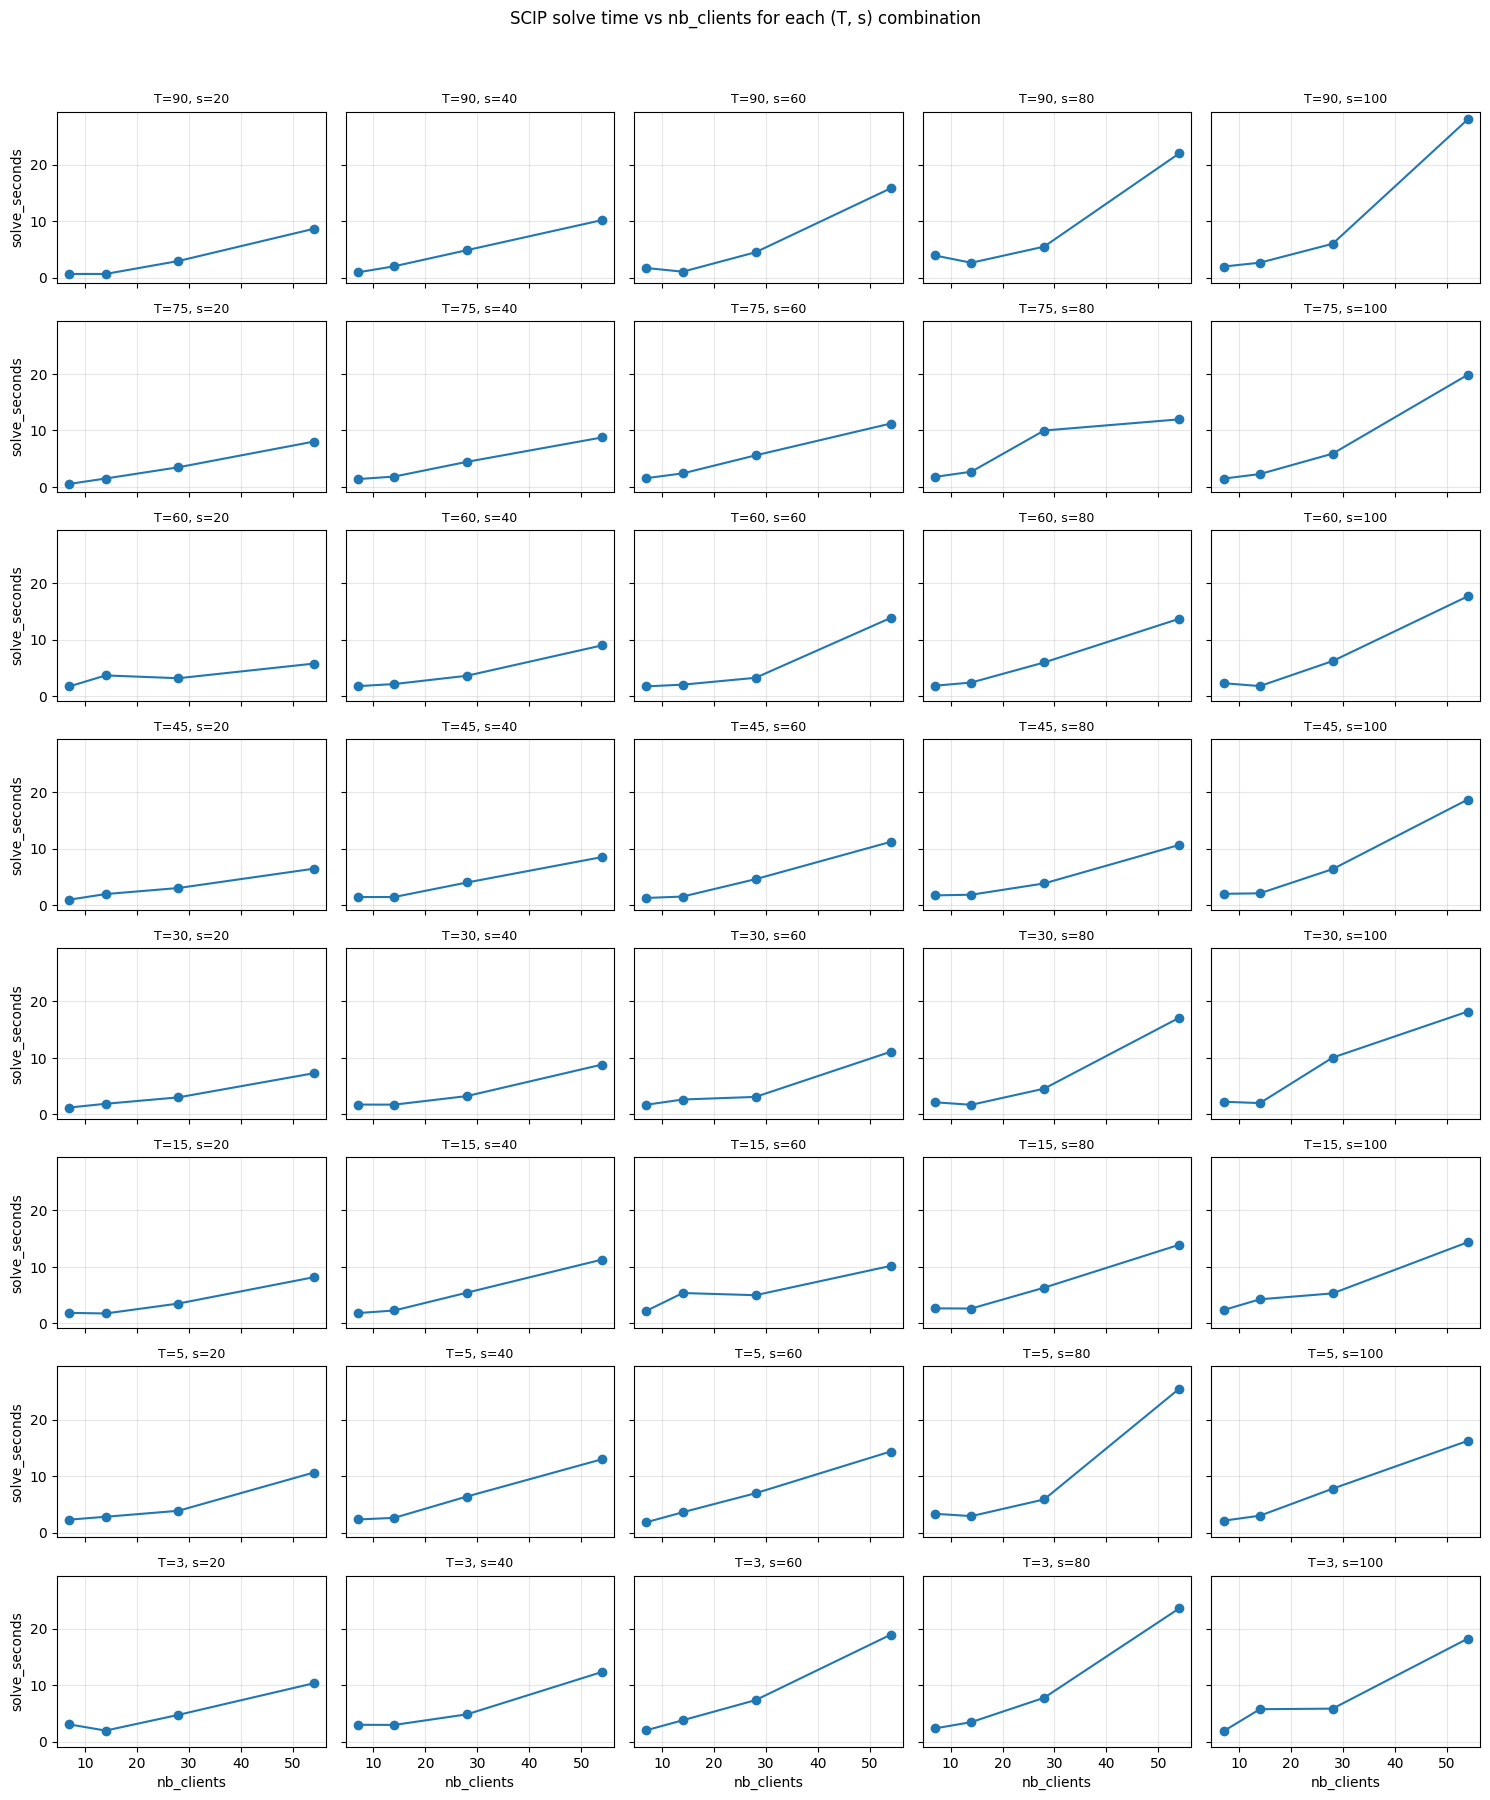

In [10]:
# One subplot per (T, s) combination: y=solve_seconds, x=nb_clients
T_vals = sorted(timing_df["T"].unique(), reverse=True)
s_vals = sorted(timing_df["s"].unique())

fig, axes = plt.subplots(
    nrows=len(T_vals),
    ncols=len(s_vals),
    figsize=(3 * len(s_vals), 2.2 * len(T_vals)),
    sharex=True,
    sharey=True,
)

for i, T_val in enumerate(T_vals):
    for j, s_val in enumerate(s_vals):
        ax = axes[i, j]
        d = timing_df[(timing_df["T"] == T_val) & (timing_df["s"] == s_val)].sort_values("nb_clients")
        ax.plot(d["nb_clients"], d["solve_seconds"], marker="o", linewidth=1.5)
        ax.set_title(f"T={T_val}, s={s_val}", fontsize=9)
        ax.grid(True, alpha=0.3)

        if i == len(T_vals) - 1:
            ax.set_xlabel("nb_clients")
        if j == 0:
            ax.set_ylabel("solve_seconds")

plt.suptitle("SCIP solve time vs nb_clients for each (T, s) combination", y=1.02)
plt.tight_layout()
plt.show()

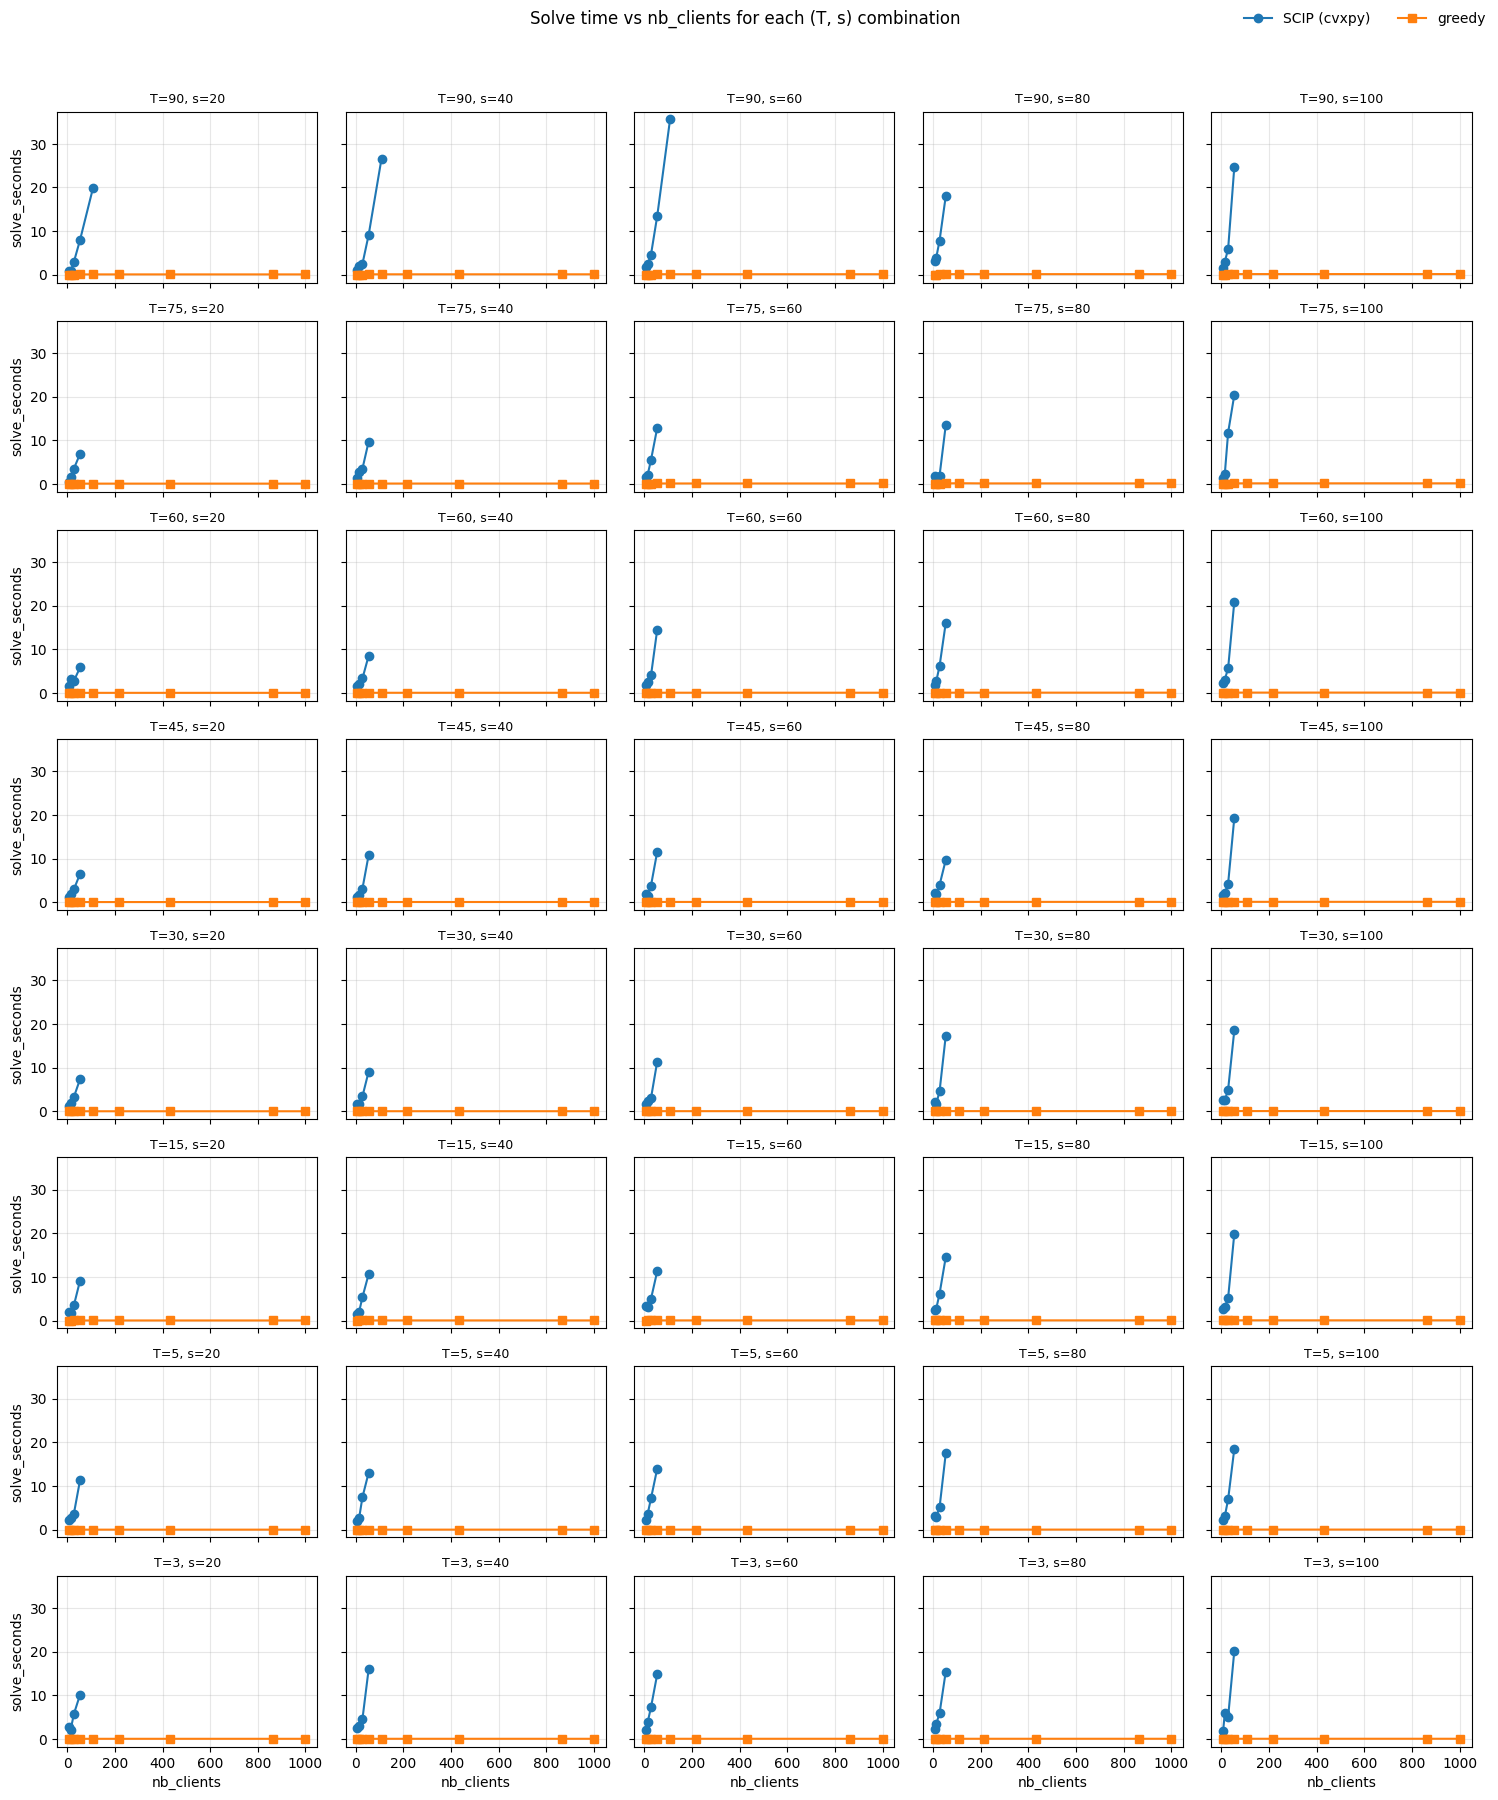

In [7]:
timing_df_greedy = pd.read_csv(MAIN_FOLDER + "/alphaF_greedy_solve_times.csv")
timing_df = pd.read_csv(MAIN_FOLDER + "/alphaF_solve_times.csv")

T_vals = sorted(timing_df["T"].unique(), reverse=True)
s_vals = sorted(timing_df["s"].unique())

fig, axes = plt.subplots(
    nrows=len(T_vals),
    ncols=len(s_vals),
    figsize=(3 * len(s_vals), 2.2 * len(T_vals)),
    sharex=True,
    sharey=True,
)

for i, T_val in enumerate(T_vals):
    for j, s_val in enumerate(s_vals):
        ax = axes[i, j]
        d = timing_df[(timing_df["T"] == T_val) & (timing_df["s"] == s_val)].sort_values("nb_clients")
        ax.plot(d["nb_clients"], d["solve_seconds"], marker="o", linewidth=1.5, color="tab:blue", label="SCIP (cvxpy)")
        dg = timing_df_greedy[(timing_df_greedy["T"] == T_val) & (timing_df_greedy["s"] == s_val)].sort_values("nb_clients")
        ax.plot(dg["nb_clients"], dg["solve_seconds"], marker="s", linewidth=1.5, color="tab:orange", label="greedy")
        ax.set_title(f"T={T_val}, s={s_val}", fontsize=9)
        ax.grid(True, alpha=0.3)

        if i == len(T_vals) - 1:
            ax.set_xlabel("nb_clients")
        if j == 0:
            ax.set_ylabel("solve_seconds")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", ncol=2, frameon=False)
plt.suptitle("Solve time vs nb_clients for each (T, s) combination", y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Scalability table (one subtable per solver): rows = (K, T) configuration,
# columns = slack time s, cell = runtime of that single run.
timing_df = pd.read_csv(MAIN_FOLDER + "/alphaF_solve_times.csv")
timing_df_greedy = pd.read_csv(MAIN_FOLDER + "/alphaF_greedy_solve_times.csv")

Korder = [7, 14, 28, 54]
Torder = [90, 75, 60, 45, 30, 15, 5, 3]
Sorder = [20, 40, 60, 80, 100]


def fmt_time(x):
    if pd.isna(x):
        return "--"
    if x < 100:
        return f"{x:.2f}"
    if x < 1000:
        return f"{x:.1f}"
    return f"{x:,.0f}".replace(",", "{,}")


def build_subtable(df, caption, label, is_scip):
    piv = df.pivot_table(index=["nb_clients", "T"], columns="s", values="solve_seconds", aggfunc="max")

    body = []
    for K in Korder:
        first = True
        for Tv in Torder:
            vals = [piv.loc[(K, Tv), sv] for sv in Sorder]
            rowmax = max(vals)  # bold the worst case in each row
            cells = []
            for v in vals:
                cell = fmt_time(v)
                if v == rowmax:
                    cell = r"\textbf{" + cell + "}"
                cells.append(cell)
            lead = rf"\multirow{{{len(Torder)}}}{{*}}{{{K}}}" if first else ""
            body.append(f"        {lead} & {Tv} & " + " & ".join(cells) + r" \\")
            first = False
        body.append(r"        \hline")
    body_tex = "\n".join(body)
    header_s = " & ".join(rf"\textbf{{{sv}}}" for sv in Sorder)

    note = ""
    if is_scip:
        n_inacc = (df["status"] == "optimal_inaccurate").sum()
        note = (
            f"\n    \\vspace{{2pt}}\\\\\n"
            f"    {{\\scriptsize\\color{{orange}} $^{{*}}$Solver capped at 1000 branch-and-bound "
            f"nodes ({n_inacc}/{len(df)} runs), so SCIP runtime is bounded and largely "
            f"budget-independent.\\par}}"
        )
        caption = caption + r"$^{*}$"

    return rf"""    \begin{{subtable}}{{\linewidth}}
    \centering
    {{%
    \color{{orange}}%
    \arrayrulecolor{{orange}}%
    {{\captionsetup{{font={{footnotesize,color=orange}}}}%
    \caption{{{caption}}}
    }}
    \label{{{label}}}
    \renewcommand{{\arraystretch}}{{1.15}}
    \setlength{{\tabcolsep}}{{4pt}}
    \begin{{tabular}}{{|c|c|c|c|c|c|c|}}
    \hline
    \multirow{{2}}{{*}}{{\shortstack{{\textbf{{Regions}} \\ \textbf{{($K$)}}}}}} &
    \multirow{{2}}{{*}}{{\shortstack{{\textbf{{Train}} \\ \textbf{{time ($T$)}}}}}} &
    \multicolumn{{5}}{{c|}}{{\textbf{{Runtime (s) at slack $s$}}}} \\
    \cline{{3-7}}
    & & {header_s} \\
    \hline
{body_tex}
    \end{{tabular}}
    \arrayrulecolor{{black}}%
    }}%{note}
    \end{{subtable}}"""


scip_table = build_subtable(
    timing_df,
    r"Exact solver (CVXPY, SCIP branch-and-bound).",
    "tab:scalability_scip",
    is_scip=True,
)
greedy_table = build_subtable(
    timing_df_greedy,
    r"Greedy submodular approximation.",
    "tab:scalability_greedy",
    is_scip=False,
)

latex_table = rf"""\begin{{table*}}[h!]
    \centering
    {{\captionsetup{{font={{footnotesize,color=orange}}}}%
    \caption{{Scheduler wall-clock runtime (seconds) for every configuration: number of
    geographical regions $K$ and base training time $T$ (rows) against slack time $s$
    (columns). The scheduling horizon is $T+s-t_{{\mathrm{{ft}}}}$ with $t_{{\mathrm{{ft}}}}=1$;
    the scheduler is run once before training. All runs on a workstation with an
    Intel Core i7-14700K CPU (8 P-cores + 12 E-cores, 28 threads, up to 5.6\,GHz)
    and 32\,GB RAM, running Pop!\_OS 22.04 LTS, using SCIP~10.0 via CVXPY~1.7.5
    (PySCIPOpt~6.2.1).}}
    \label{{tab:scalability}}
    }}
    \scriptsize
    \renewcommand{{\arraystretch}}{{1.05}}
    \setlength{{\tabcolsep}}{{1pt}}
{scip_table}

    \vspace{{1em}}

{greedy_table}
\end{{table*}}"""

print(latex_table)

## Old Greedy Algo vs New Greedy Algo

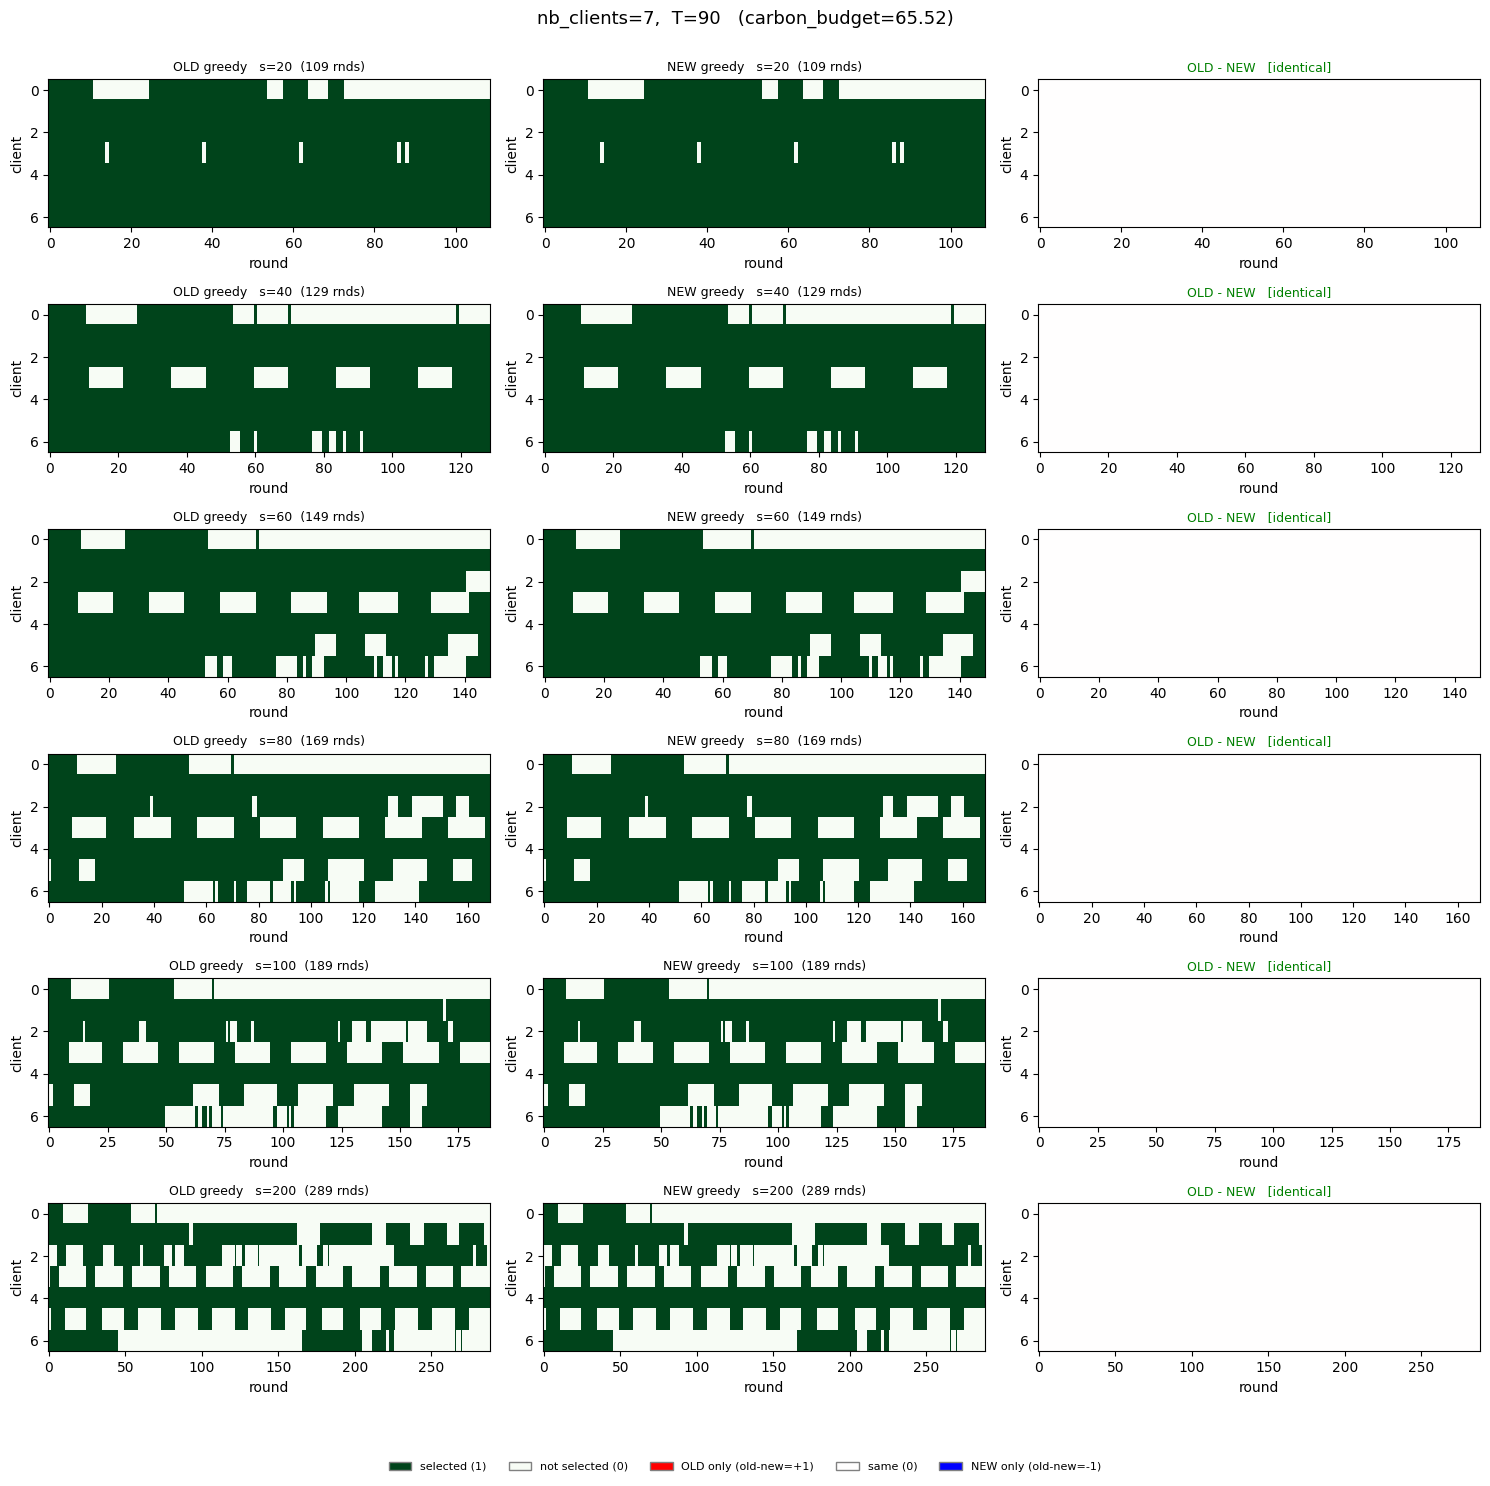

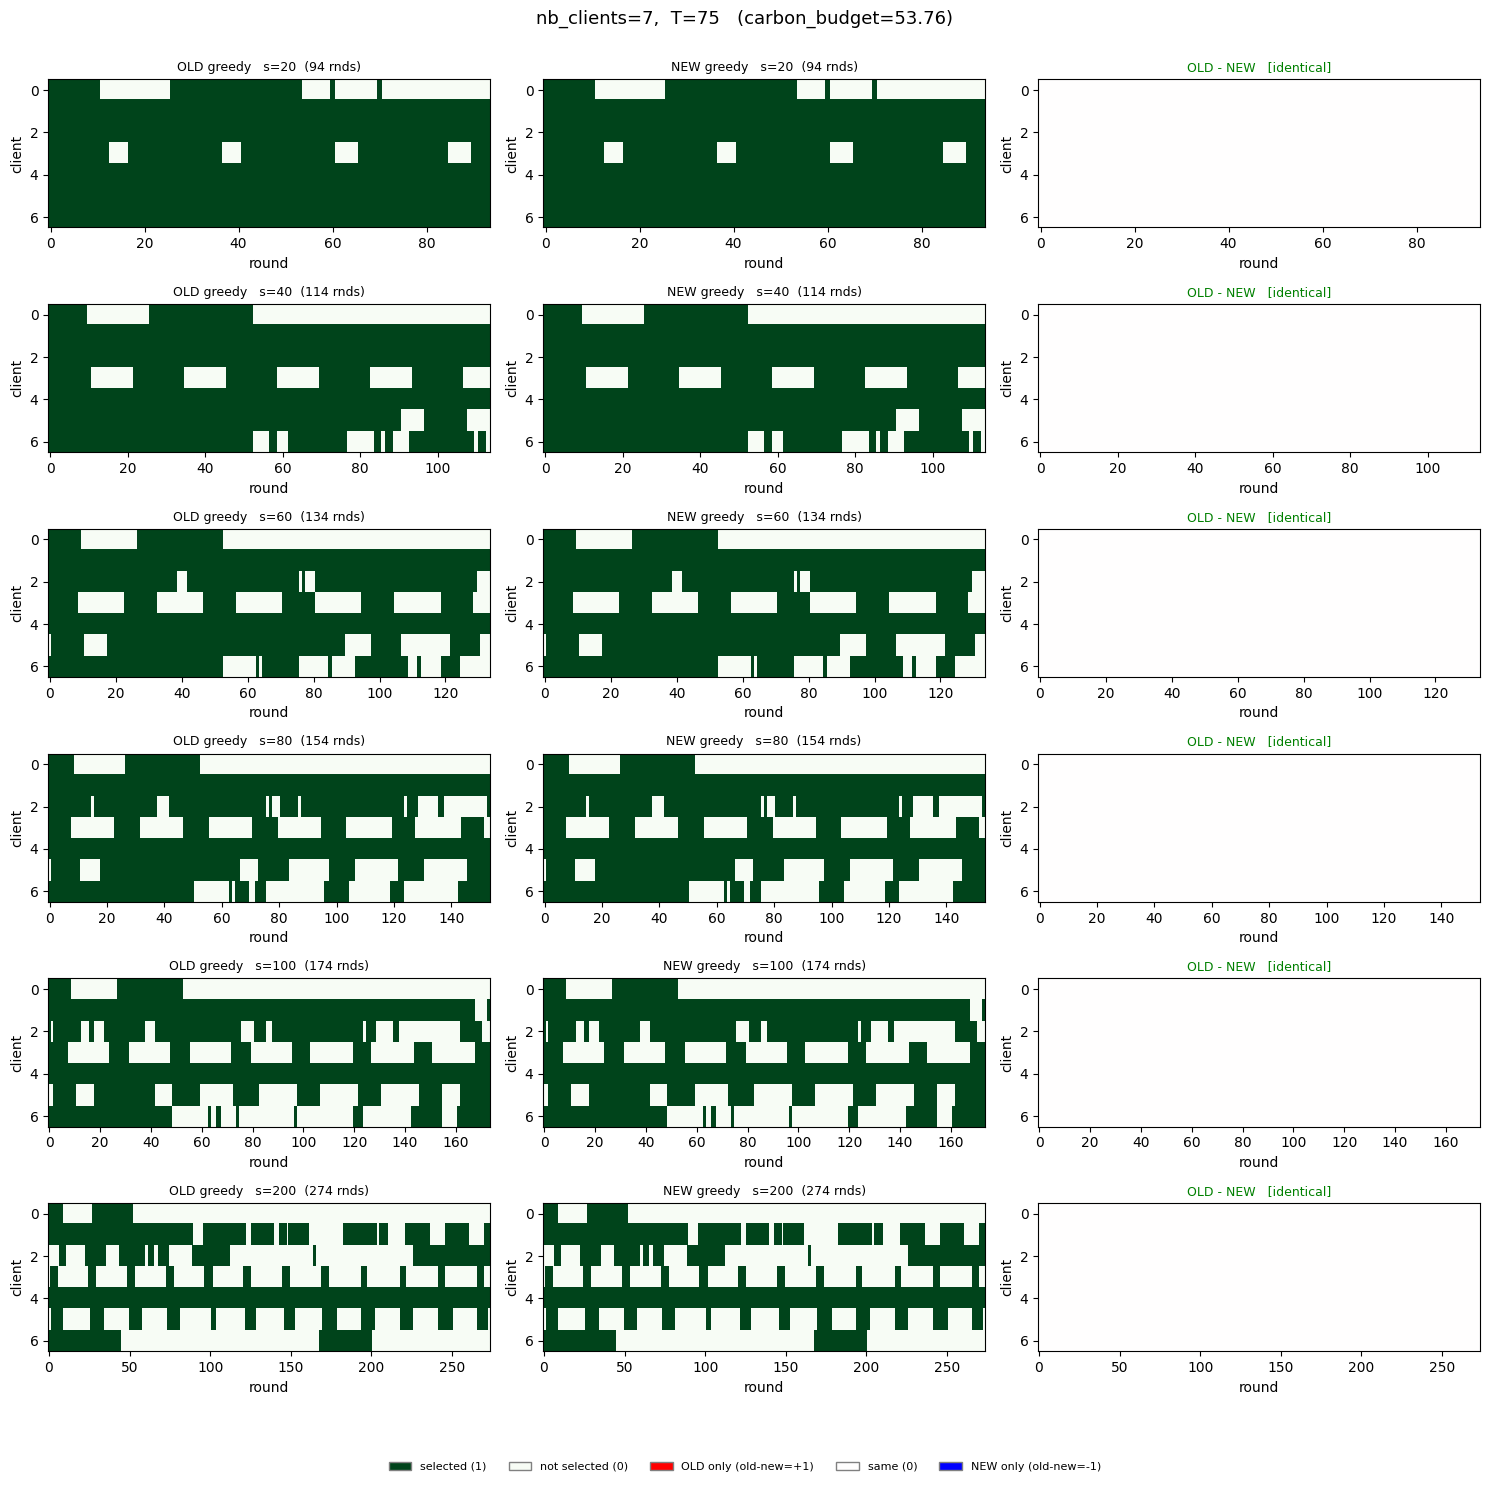

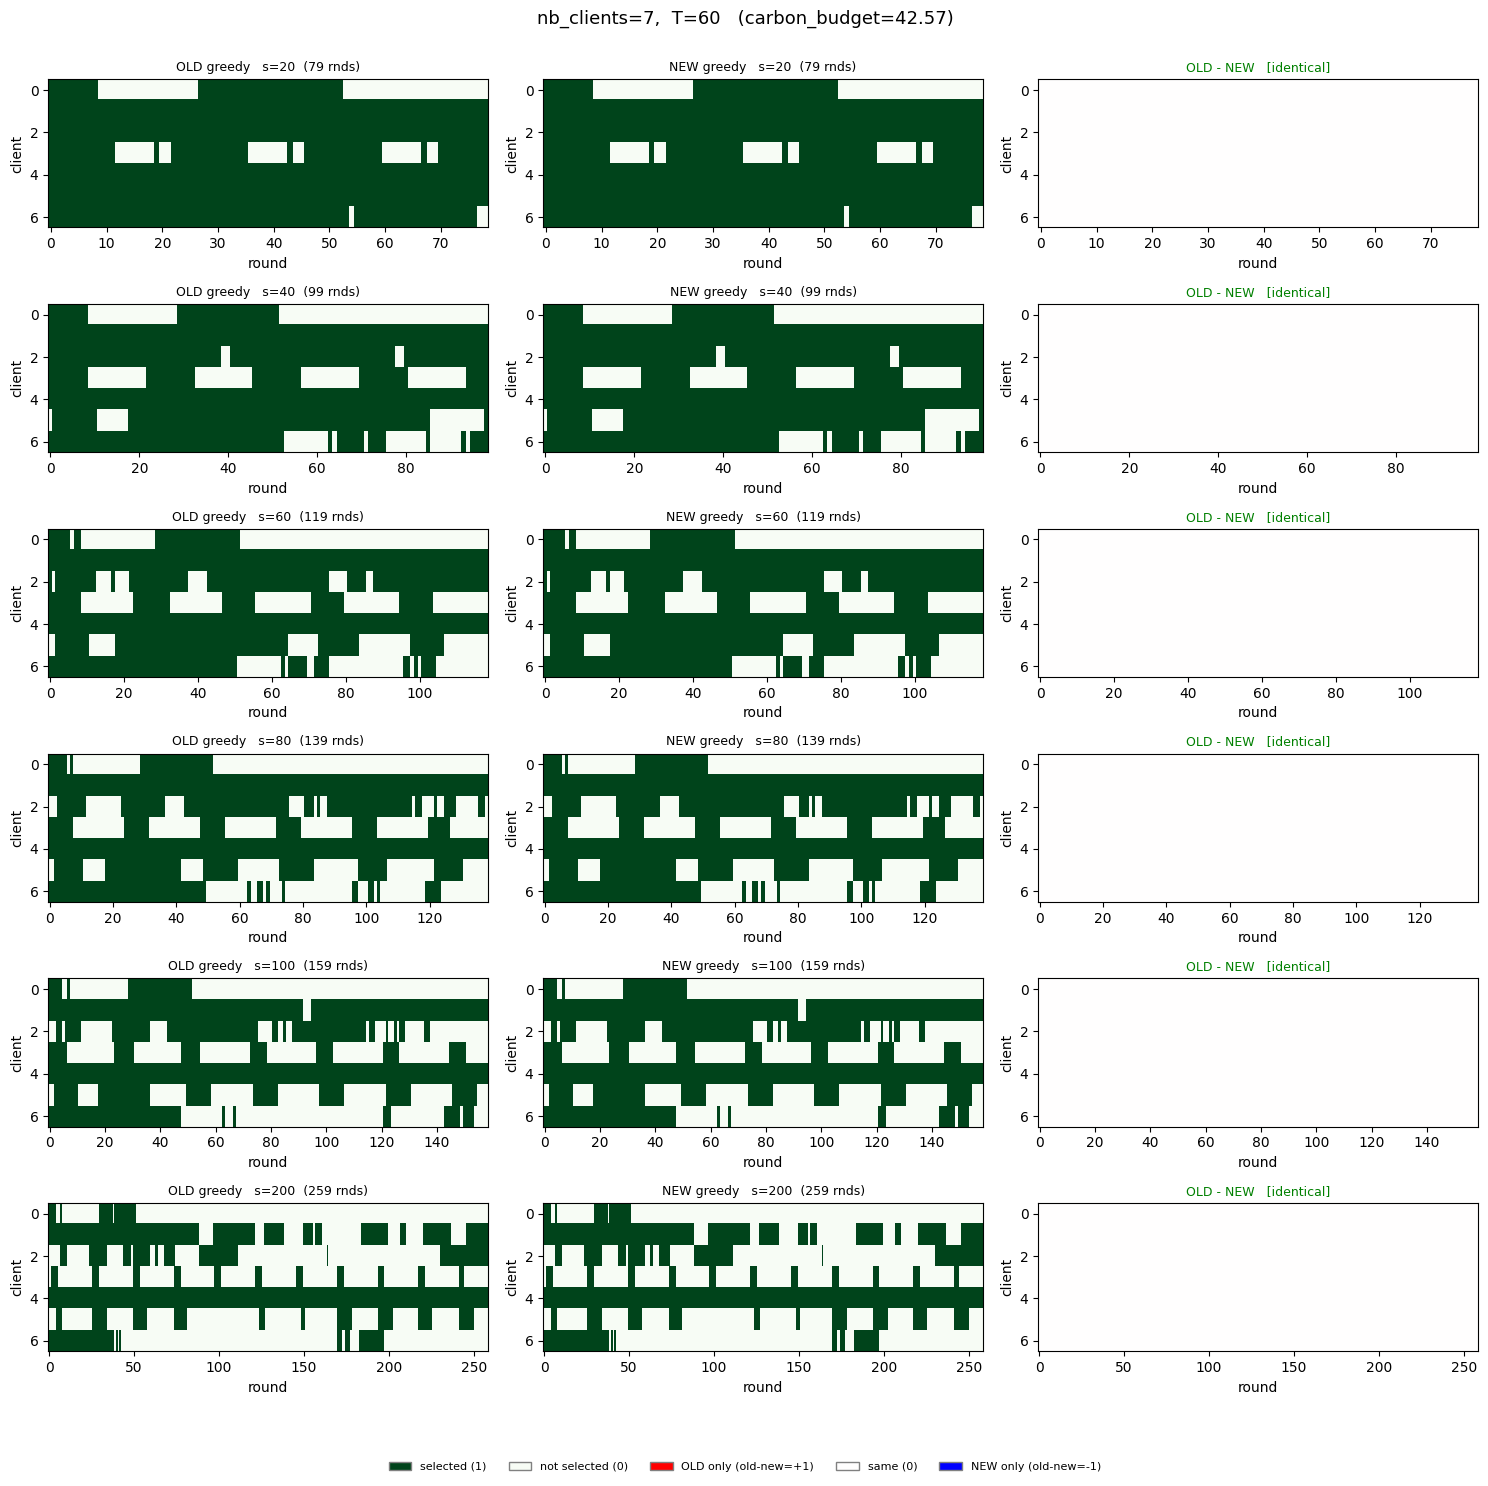

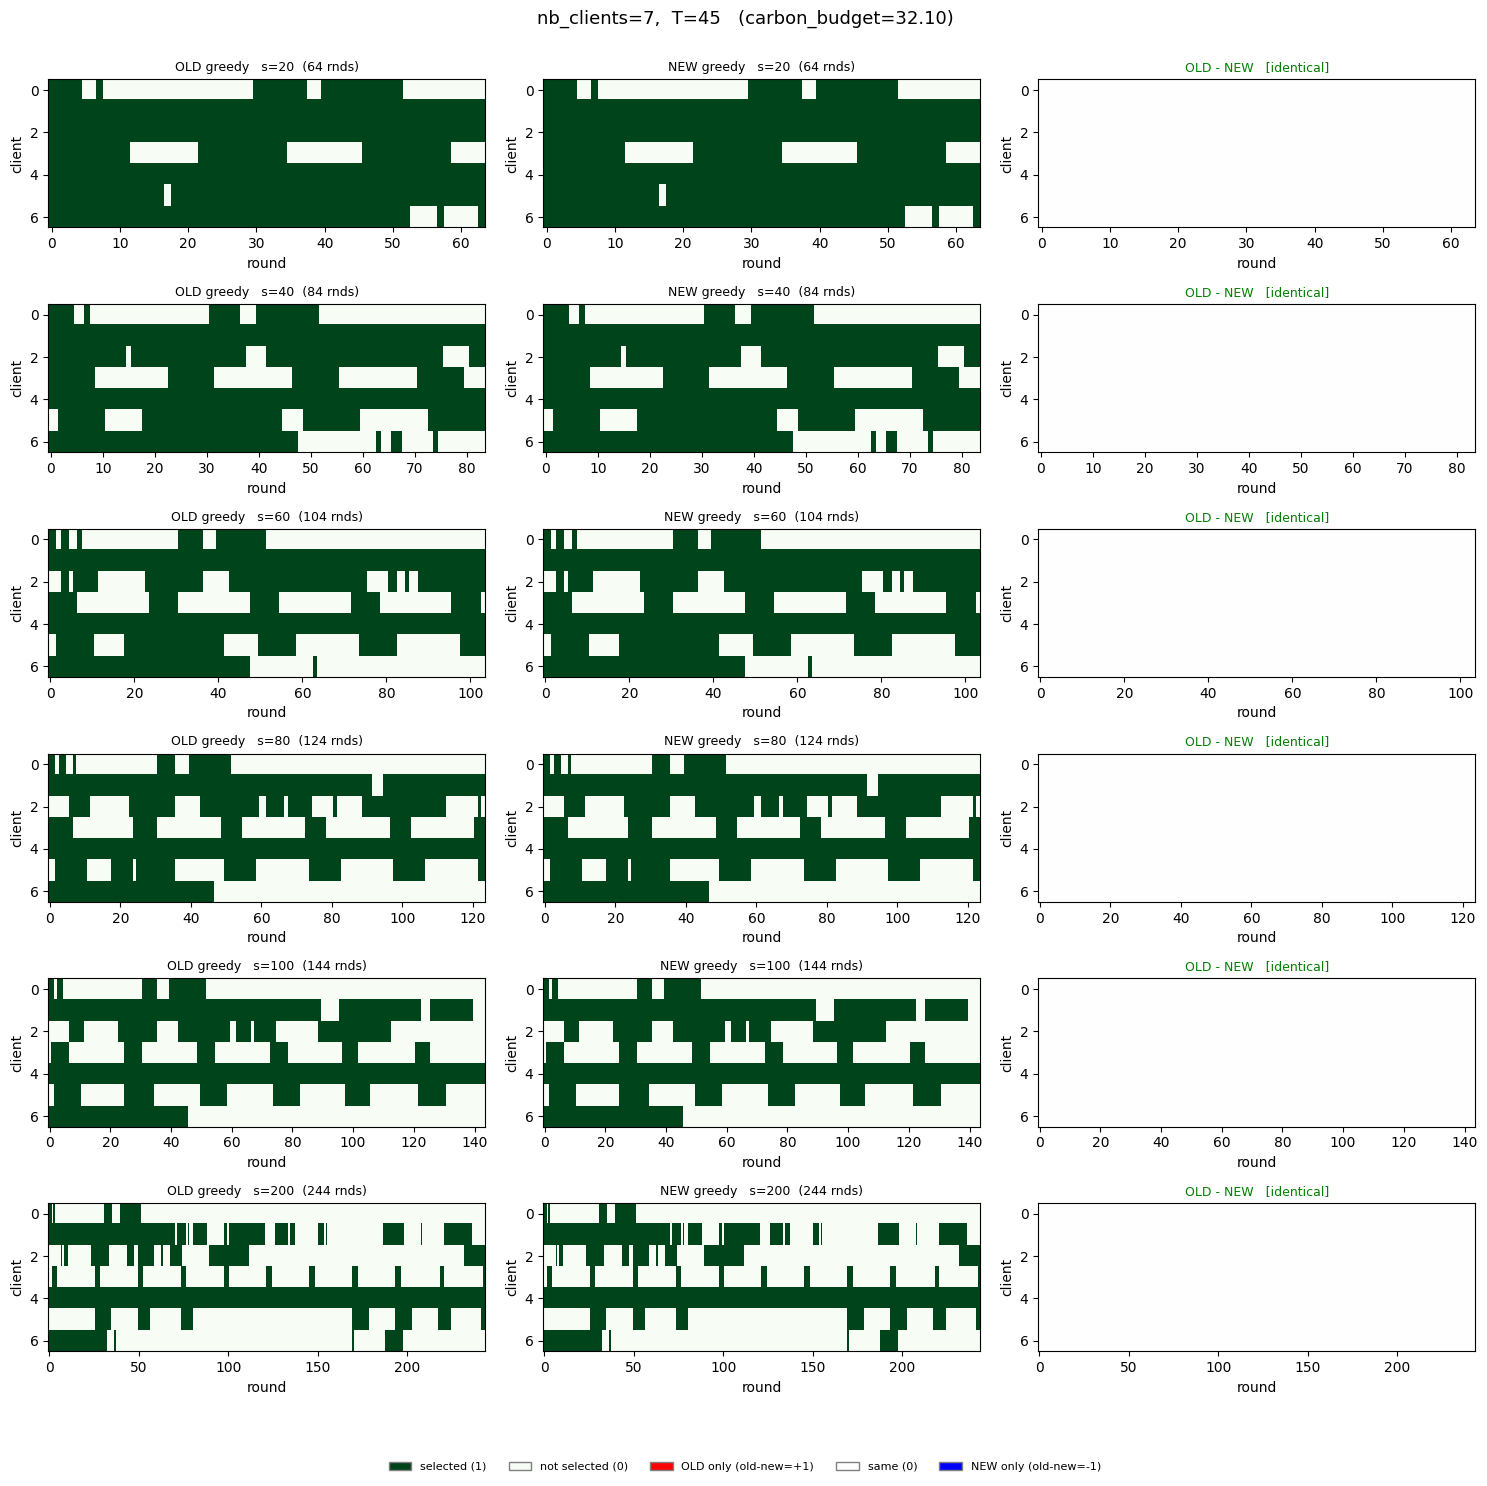

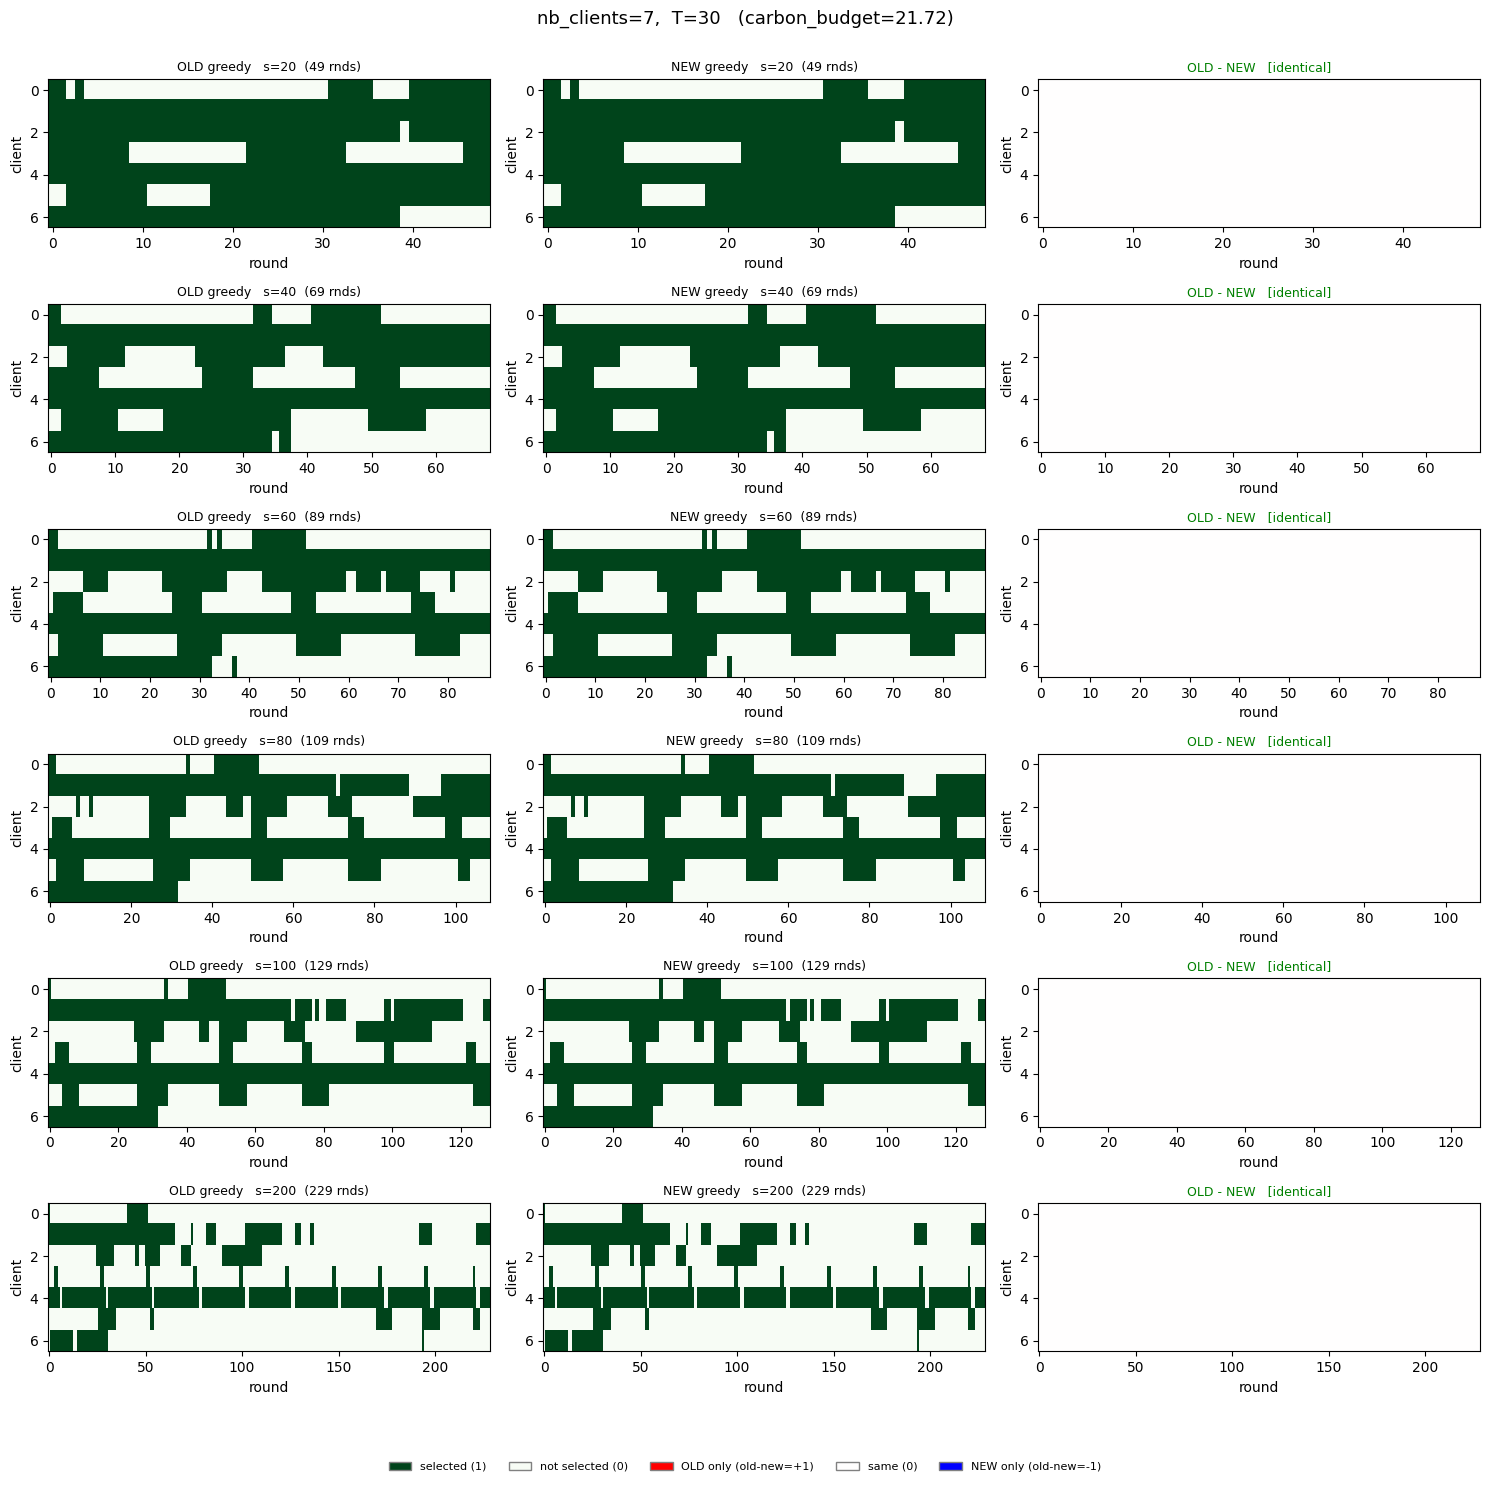

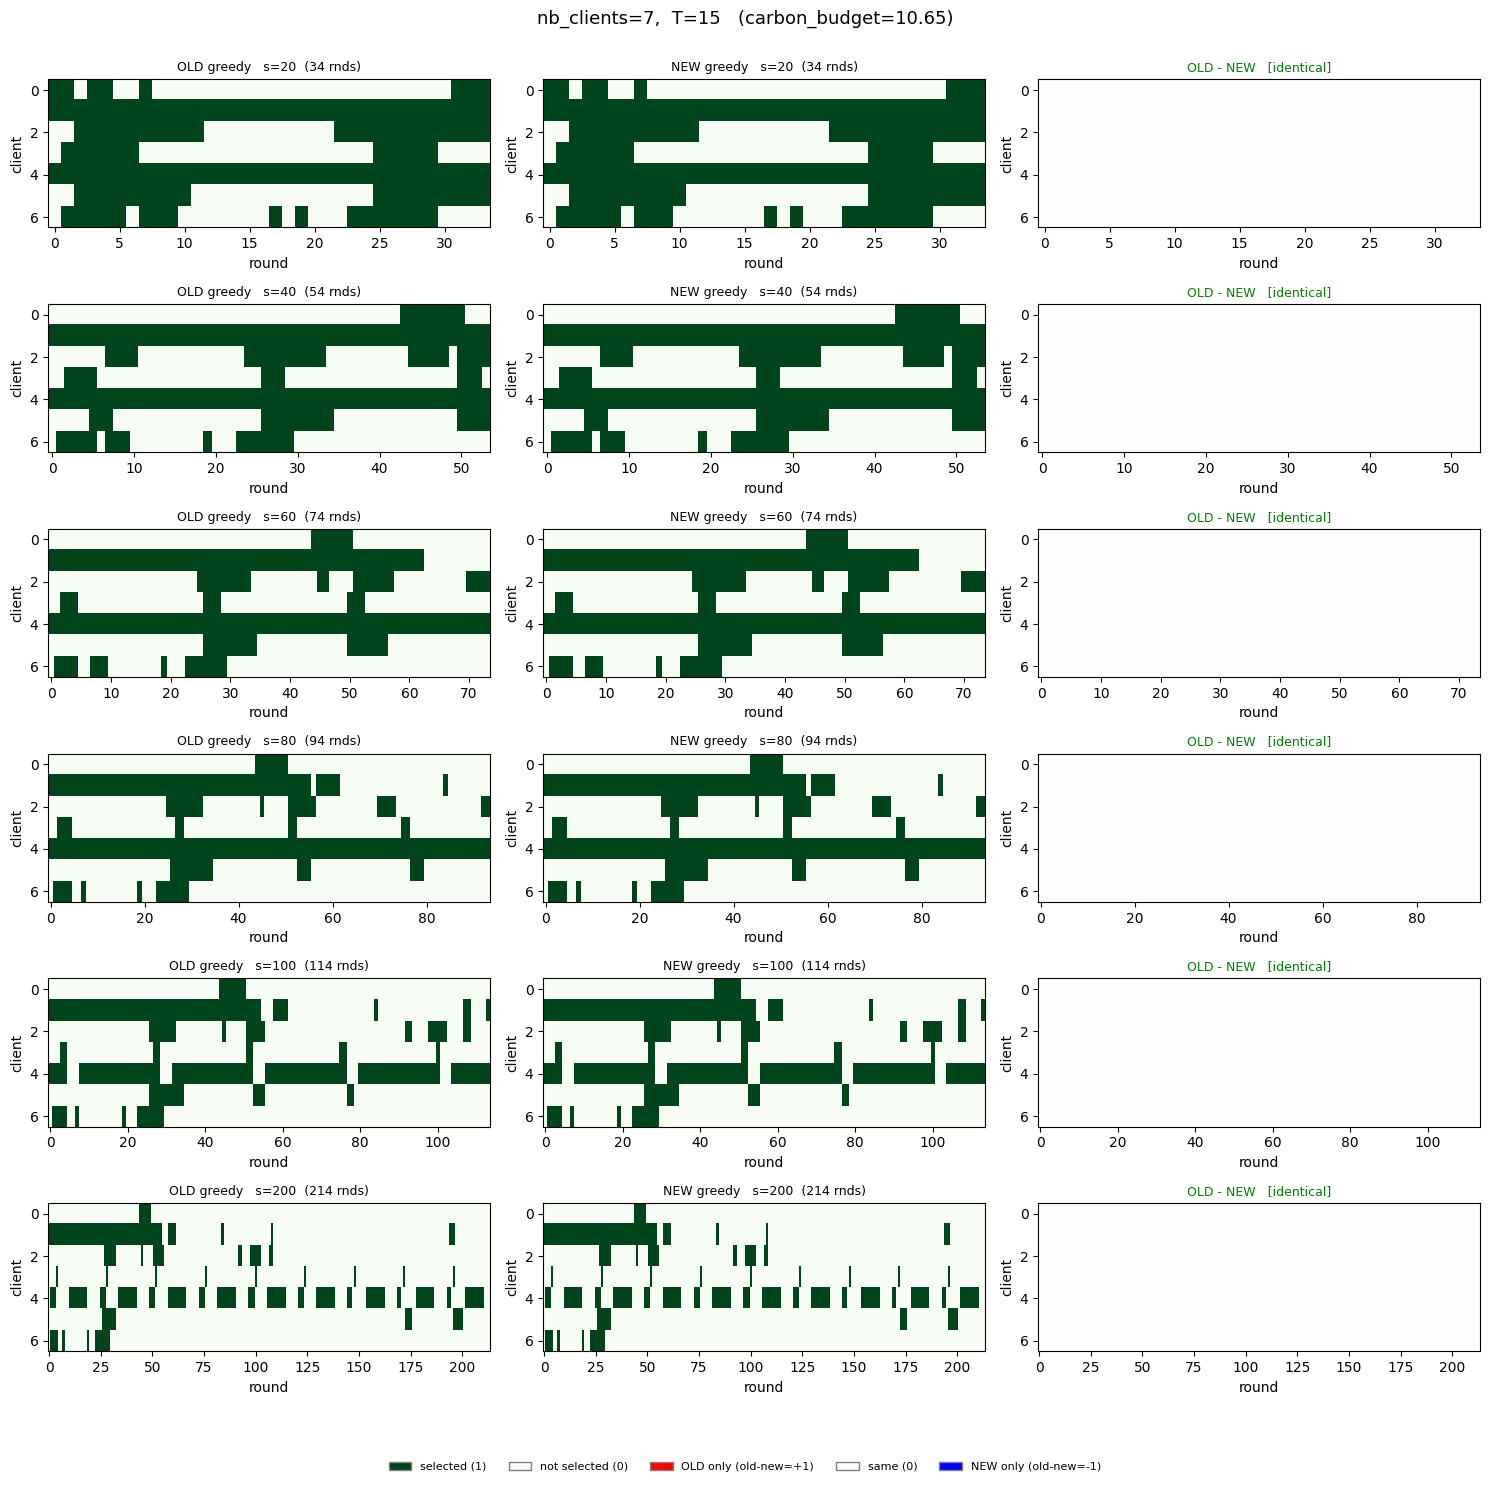

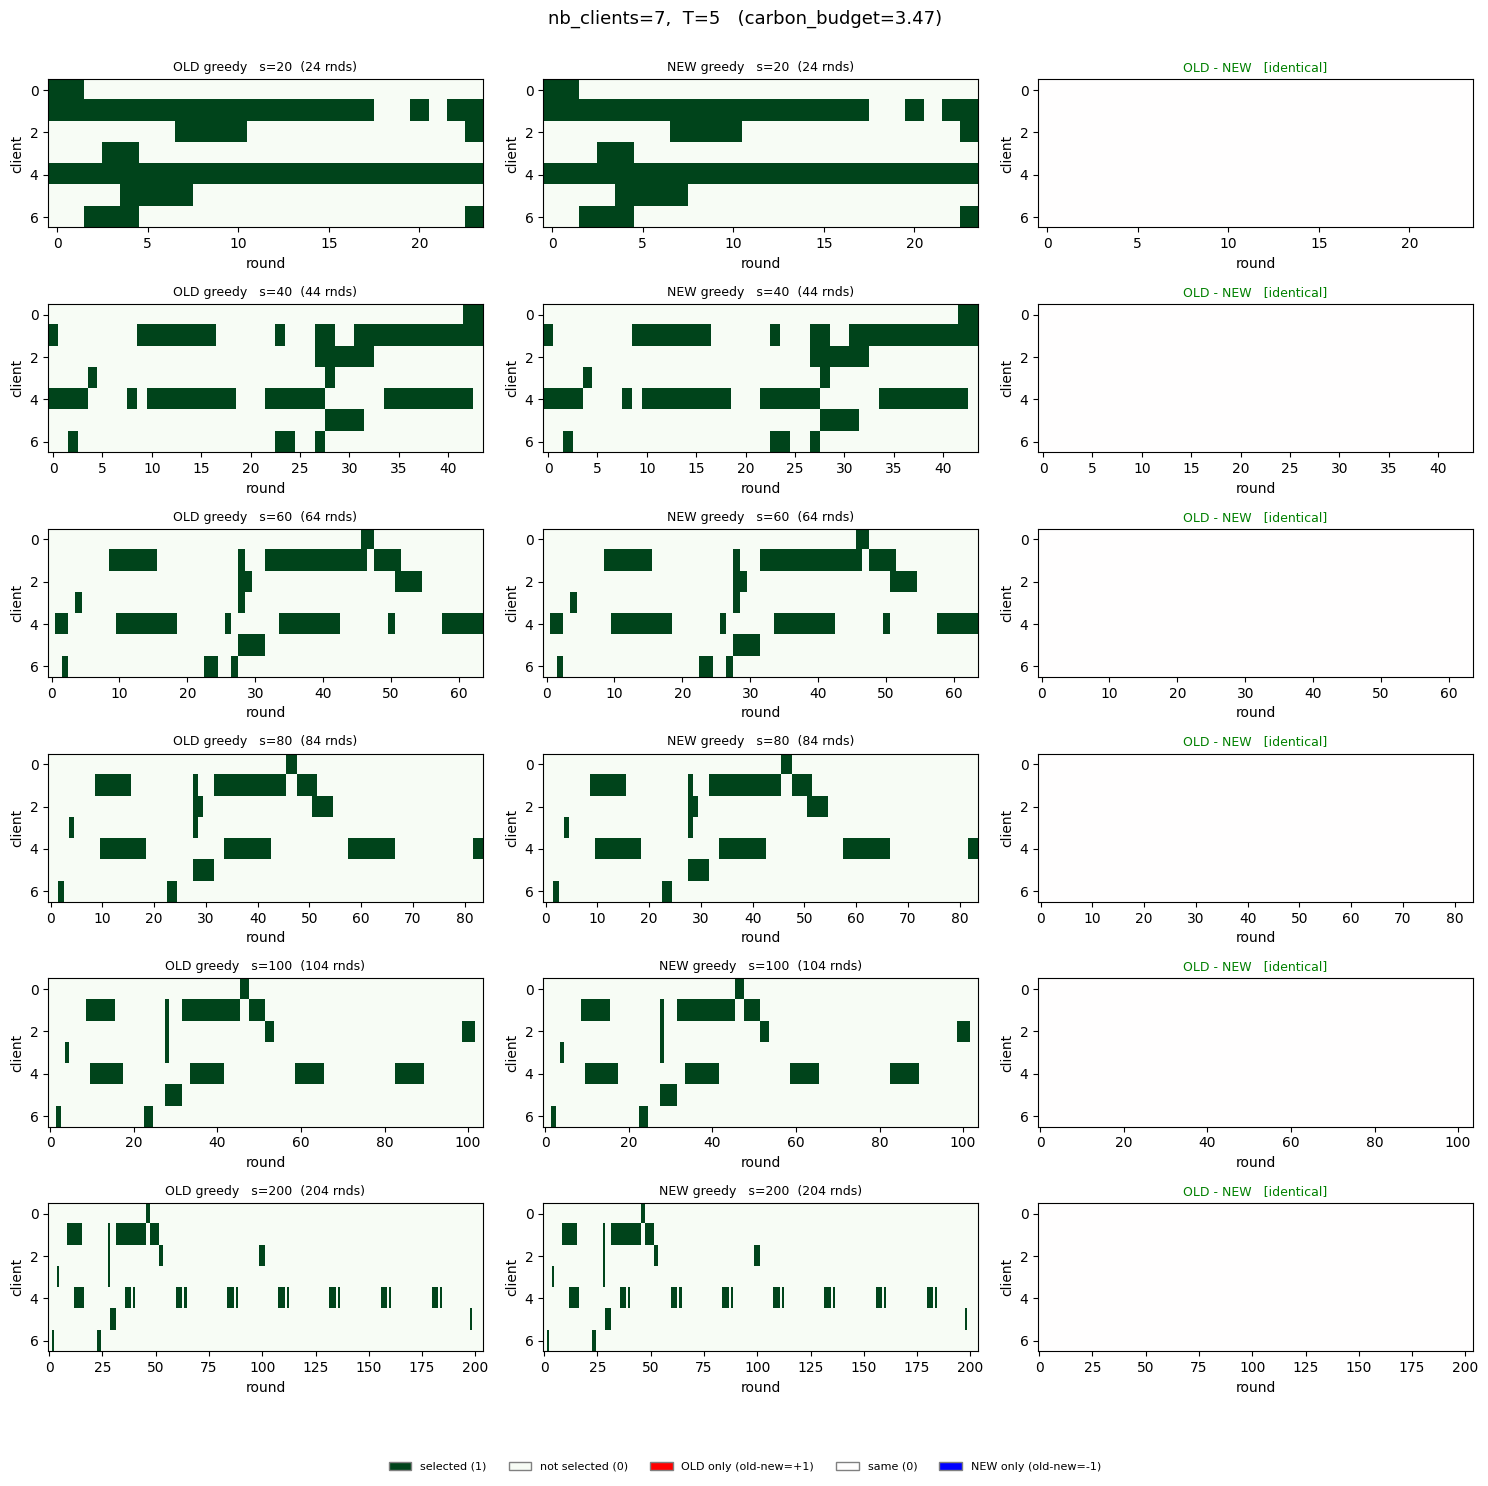

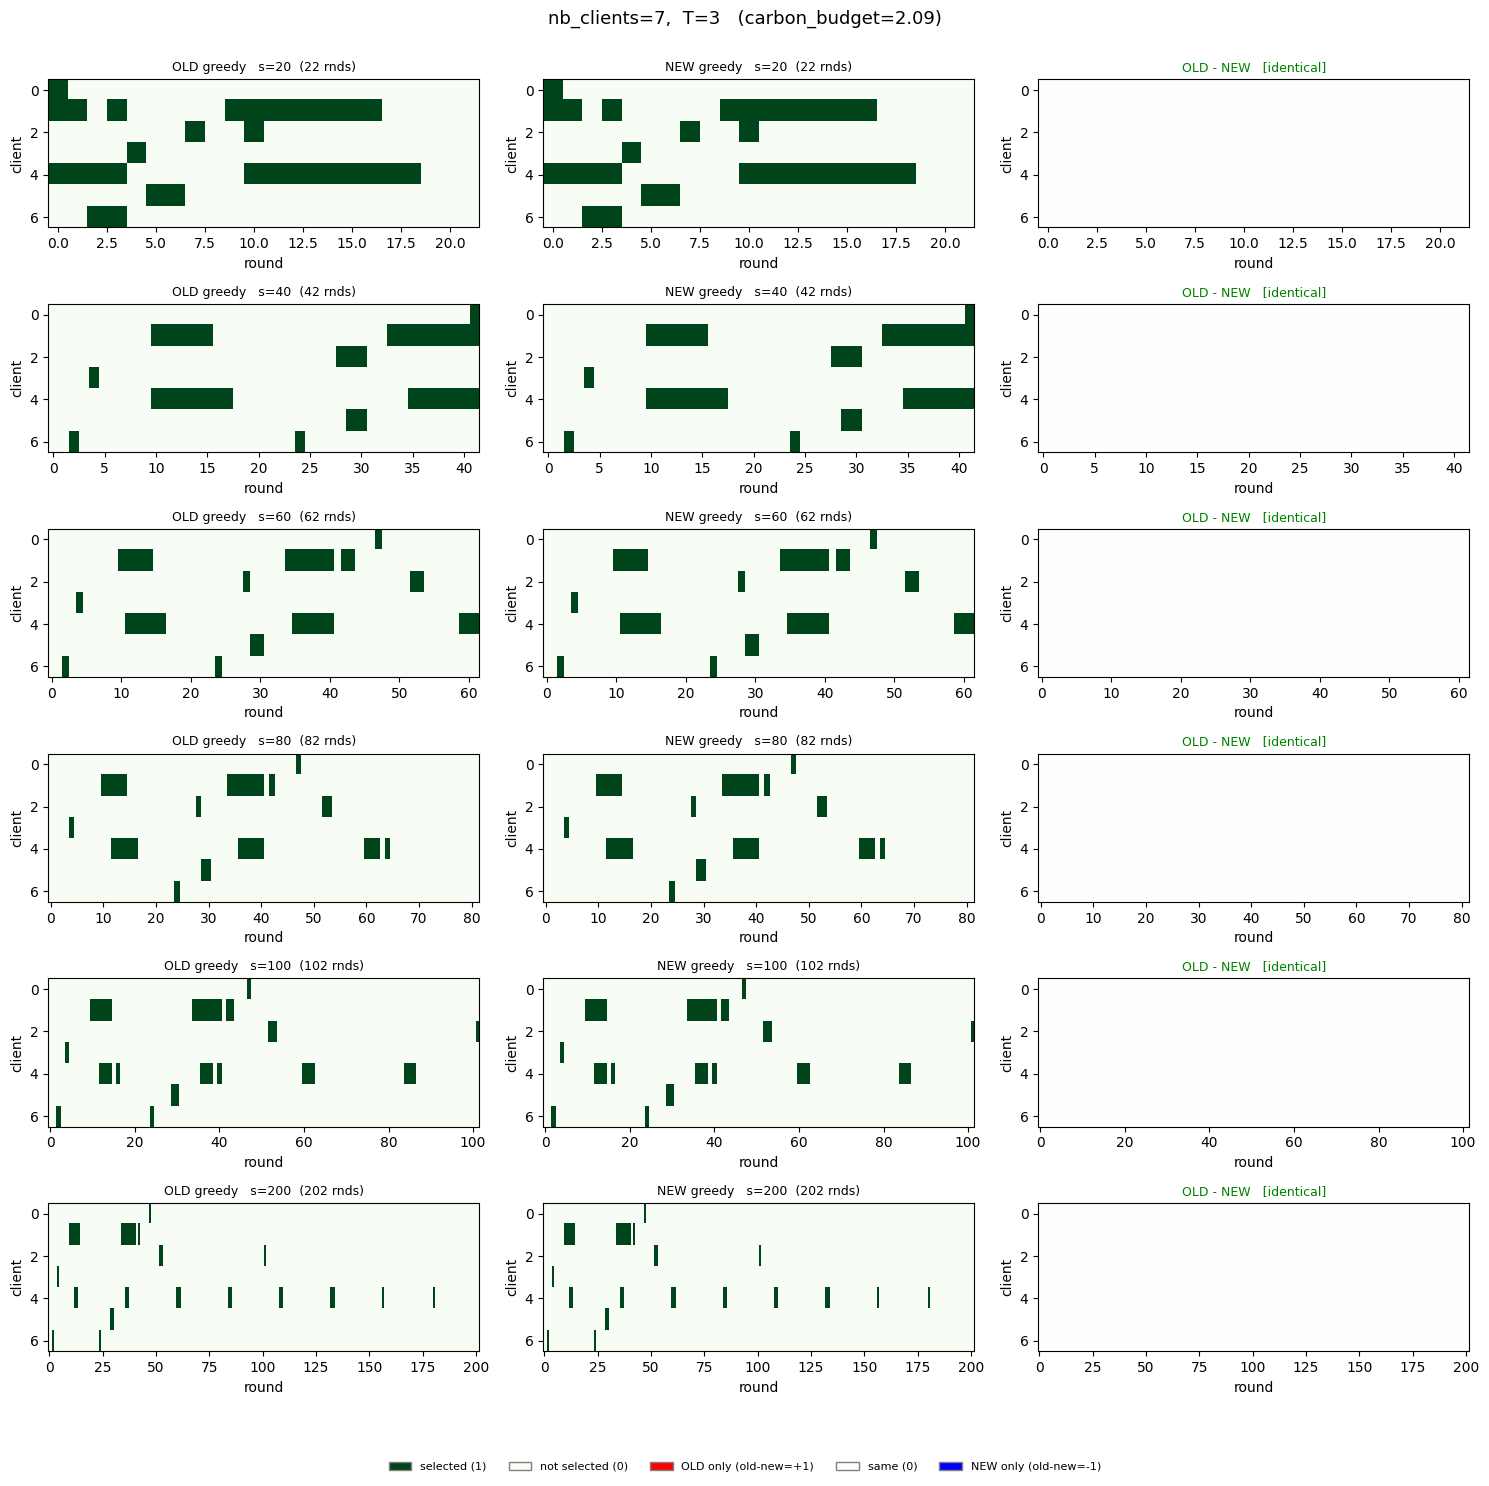

configurations compared : 48
all identical           : True
max differing cells     : 0


,T,s,n_rounds,picks_old,picks_new,n_diff_cells,identical,obj_old,obj_new
0,90,20,109,699,699,0,True,9.206293,9.206293
1,90,40,129,755,755,0,True,9.262489,9.262489
2,90,60,149,792,792,0,True,9.295565,9.295565
3,90,80,169,825,825,0,True,9.322630,9.322630
4,90,100,189,859,859,0,True,9.349288,9.349288
5,90,200,289,998,998,0,True,9.539035,9.539035
6,75,20,94,587,587,0,True,9.052407,9.052407
7,75,40,114,637,637,0,True,9.112773,9.112773
8,75,60,134,675,675,0,True,9.151841,9.151841
9,75,80,154,706,706,0,True,9.179999,9.179999


In [4]:
# ===========================================================================
# OLD greedy (greedy.py)  vs  NEW greedy (greedy_improv.py): same avail_mat?
# nb_clients = 7, every T, and s in {20, 40, 60, 80, 100, 200}. For each (T, s)
# the availability matrix of each solver is plotted side by side (+ their
# difference) so the two can be compared cell-by-cell visually.
#   NOTE: runtime is dominated by the OLD O(N^2) greedy -> the full sweep can
#   take a few minutes.
# ===========================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from av_mat_generation.CI_based.greedy import GreedyProblem as GreedyOld
from av_mat_generation.CI_based.greedy_improv import GreedyProblem as GreedyNew

nb_clients   = 7
T_list_chk   = [90, 75, 60, 45, 30, 15, 5, 3]
s_values_chk = [20, 40, 60, 80, 100, 200]
alpha_f_chk  = 0.1                       # same alpha_f as the rest of the notebook

# colour legend shared by every figure
sel_handles = [
    mpatches.Patch(facecolor=plt.cm.Greens(1.0), edgecolor="gray", label="selected (1)"),
    mpatches.Patch(facecolor=plt.cm.Greens(0.0), edgecolor="gray", label="not selected (0)"),
]
diff_handles = [
    mpatches.Patch(facecolor=plt.cm.bwr(1.0), edgecolor="gray", label="OLD only (old-new=+1)"),
    mpatches.Patch(facecolor=plt.cm.bwr(0.5), edgecolor="gray", label="same (0)"),
    mpatches.Patch(facecolor=plt.cm.bwr(0.0), edgecolor="gray", label="NEW only (old-new=-1)"),
]

# carbon budget per T, built exactly like the greedy timing cell above
win0 = Window(start_time=start_time, out_folder=MAIN_FOLDER,
              n_rounds=max_rounds, custom_client_list=nb_clients)
budget_per_T = (win0.get_GHG_matrix().sum().cumsum()
                .to_numpy().take([89, 74, 59, 44, 29, 14, 4, 2]))

check_rows = []
for ii, Tv in enumerate(T_list_chk):
    carbon_budget = budget_per_T[ii]
    fig, axes = plt.subplots(len(s_values_chk), 3,
                             figsize=(15, 2.4 * len(s_values_chk)), squeeze=False)
    fig.suptitle(f"nb_clients={nb_clients},  T={Tv}   (carbon_budget={carbon_budget:.2f})",
                 fontsize=13, y=1.002)
    for r, s in enumerate(s_values_chk):
        try:
            # same construction as the greedy timing cell
            win1 = Window(start_time=start_time, out_folder=MAIN_FOLDER,
                          n_rounds=Tv + s, custom_client_list=nb_clients)
            win  = Window(start_time=start_time, out_folder=MAIN_FOLDER,
                          n_rounds=Tv + s - ft, custom_client_list=nb_clients)
            corrected_budget = carbon_budget - win1.get_GHG_matrix().to_numpy()[:, -ft:].sum()
            GHG_df = win.get_GHG_matrix()
            w = np.ones(win.n_rounds)

            pb_old = GreedyOld(GHG_df, alpha_f_chk, w); pb_old.greedy_optimization(corrected_budget)
            pb_new = GreedyNew(GHG_df, alpha_f_chk, w); pb_new.greedy_optimization(corrected_budget)

            A_old, A_new = pb_old.A, pb_new.A
            n_diff    = int(np.count_nonzero(A_old - A_new))   # differing cells
            identical = n_diff == 0
            check_rows.append(dict(
                T=Tv, s=s, n_rounds=win.n_rounds,
                picks_old=int(A_old.sum()), picks_new=int(A_new.sum()),
                n_diff_cells=n_diff, identical=identical,
                obj_old=pb_old.obj_func(A_old), obj_new=pb_new.obj_func(A_new),
            ))

            axes[r][0].imshow(A_old, aspect="auto", cmap="Greens", vmin=0, vmax=1, interpolation="nearest")
            axes[r][0].set_title(f"OLD greedy   s={s}  ({win.n_rounds} rnds)", fontsize=9)
            axes[r][1].imshow(A_new, aspect="auto", cmap="Greens", vmin=0, vmax=1, interpolation="nearest")
            axes[r][1].set_title(f"NEW greedy   s={s}  ({win.n_rounds} rnds)", fontsize=9)
            axes[r][2].imshow(A_old - A_new, aspect="auto", cmap="bwr", vmin=-1, vmax=1, interpolation="nearest")
            tag = "identical" if identical else f"DIFFERENT ({n_diff} cells)"
            axes[r][2].set_title(f"OLD - NEW   [{tag}]", fontsize=9,
                                 color=("green" if identical else "red"))
            for c in range(3):
                axes[r][c].set_xlabel("round"); axes[r][c].set_ylabel("client")
        except Exception as e:
            for c in range(3):
                axes[r][c].text(0.5, 0.5, f"s={s}\nfailed:\n{e}", ha="center", va="center",
                                fontsize=8, transform=axes[r][c].transAxes)
                axes[r][c].set_axis_off()
            check_rows.append(dict(T=Tv, s=s, identical=None, n_diff_cells=None,
                                   status=f"failed: {e}"))
    # shared colour legend at the bottom of each figure
    fig.legend(handles=sel_handles + diff_handles, loc="lower center", ncol=5,
               frameon=False, fontsize=8, bbox_to_anchor=(0.5, -0.02))
    fig.tight_layout(rect=[0, 0.03, 1, 1])
    plt.show()

check_df = pd.DataFrame(check_rows)
ok = check_df["identical"].dropna()
print(f"configurations compared : {len(ok)}")
print(f"all identical           : {bool(ok.all()) if len(ok) else 'n/a'}")
print(f"max differing cells     : {int(check_df['n_diff_cells'].dropna().max()) if len(ok) else 'n/a'}")
check_df
